In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


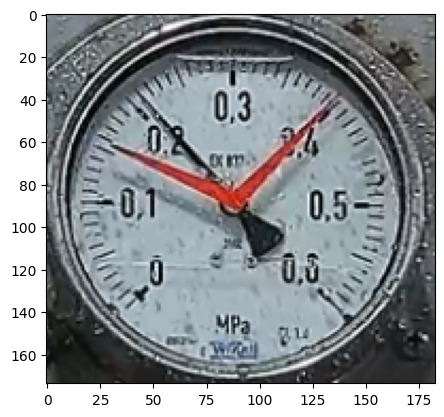

In [55]:
img = cv2.imread(r"E:\demo\py\test01\19344550-82cc-4b28-be7a-56d3fd20c35e.png")  # RGB
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

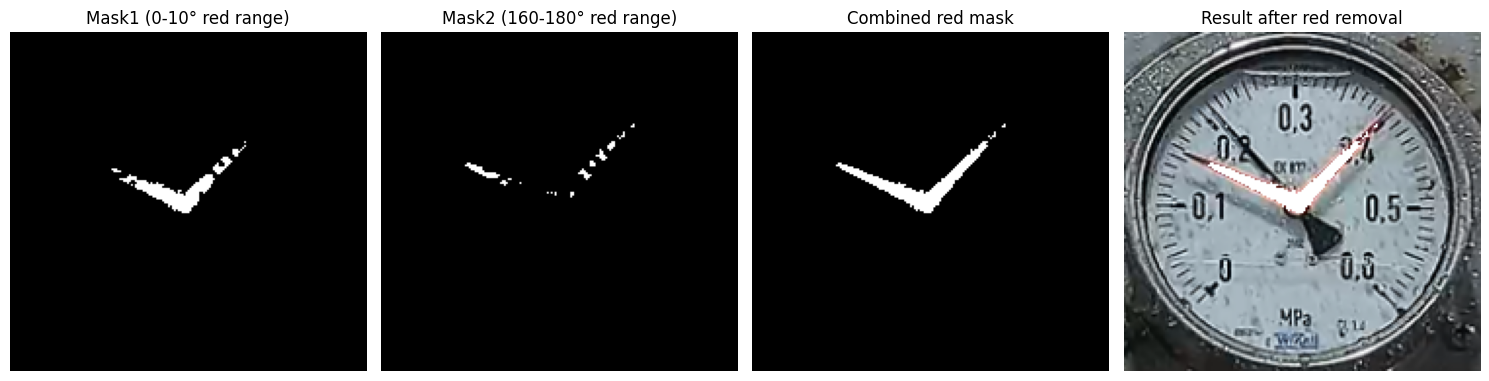

红色区域掩码已保存为变量 red_region_mask
掩码形状: (174, 183)
红色像素数量: 546


In [56]:
result = img.copy()
# 红色指针抹除
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
# 检测红色区域：将图像转换到HSV色彩空间
# 定义两个红色范围（0-10度和160-180度）来
# 捕获完整的红色色调
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])

# 使用cv2.inRange()创建掩膜
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
red_mask = mask1 + mask2

# 显示mask1和mask2以及合并后的red_mask
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.imshow(mask1, cmap='gray')
plt.title('Mask1 (0-10° red range)')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(mask2, cmap='gray')
plt.title('Mask2 (160-180° red range)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(red_mask, cmap='gray')
plt.title('Combined red mask')
plt.axis('off')

# 将红色区域设置为白色
result[red_mask > 0] = [255, 255, 255]
plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Result after red removal')
plt.axis('off')

plt.tight_layout()
plt.show()

red_region_mask = red_mask
print(f"红色区域掩码已保存为变量 red_region_mask")
print(f"掩码形状: {red_region_mask.shape}")
print(f"红色像素数量: {np.sum(red_region_mask > 0)}")

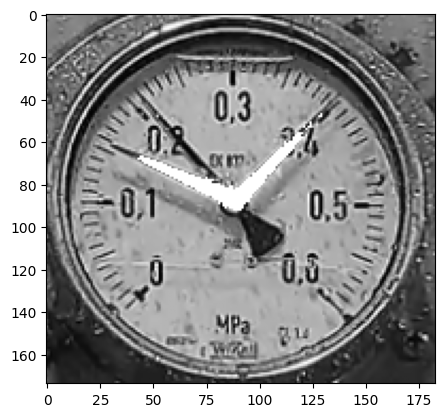

In [57]:
# 灰度化 - 将彩色图像转换为单通道
gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap='gray')
plt.show()

(np.float64(-0.5), np.float64(182.5), np.float64(173.5), np.float64(-0.5))

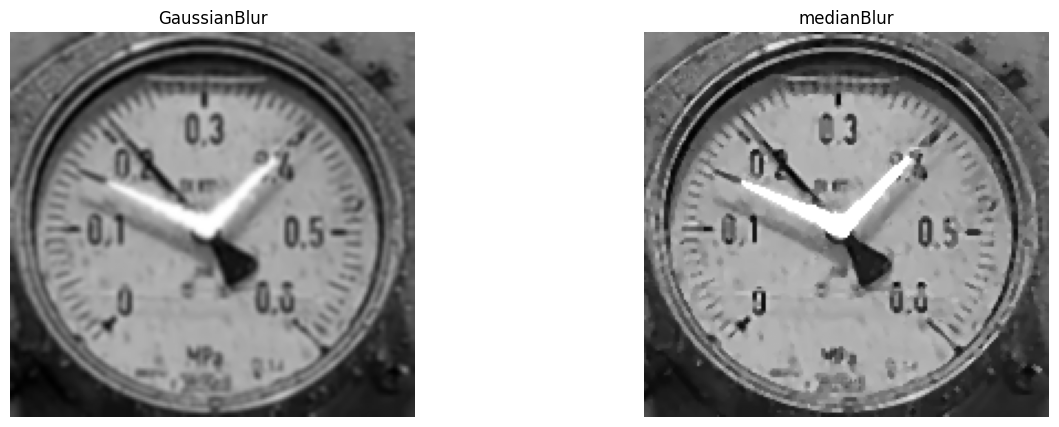

In [58]:
# 高斯平滑 减少噪声，避免检测到过多细小边缘
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
blurred2 = cv2.medianBlur(gray, 3, 0)

"""
    plt.subplot(1, 4, 2)
plt.imshow(mask2, cmap='gray')
plt.title('Mask2 (160-180° red range)')
plt.axis('off')
"""
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(blurred, cmap='gray')
plt.title("GaussianBlur")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred2, cmap="gray")
plt.title("medianBlur")
plt.axis("off")

手动阈值: 144
OTSU阈值: 114.0


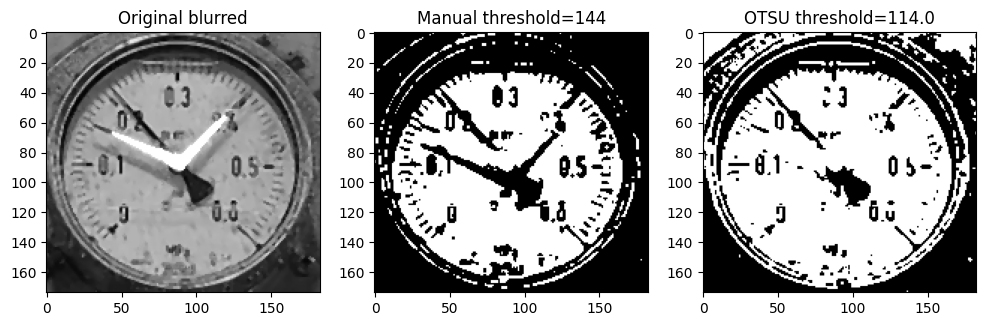

In [59]:
# 原来的固定阈值
_, thresh_manual = cv2.threshold(blurred2, 144, 255, cv2.THRESH_BINARY)

# OTSU自动阈值
otsu_value, thresh_otsu = cv2.threshold(blurred2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"手动阈值: 144")
print(f"OTSU阈值: {otsu_value:.1f}")

# 对比显示
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(blurred2, cmap="gray")
plt.title('Original blurred')

plt.subplot(132)
plt.imshow(thresh_manual, cmap='gray')
plt.title(f'Manual threshold=144')

plt.subplot(133)
plt.imshow(thresh_otsu, cmap='gray')
plt.title(f'OTSU threshold={otsu_value:.1f}')
plt.show()

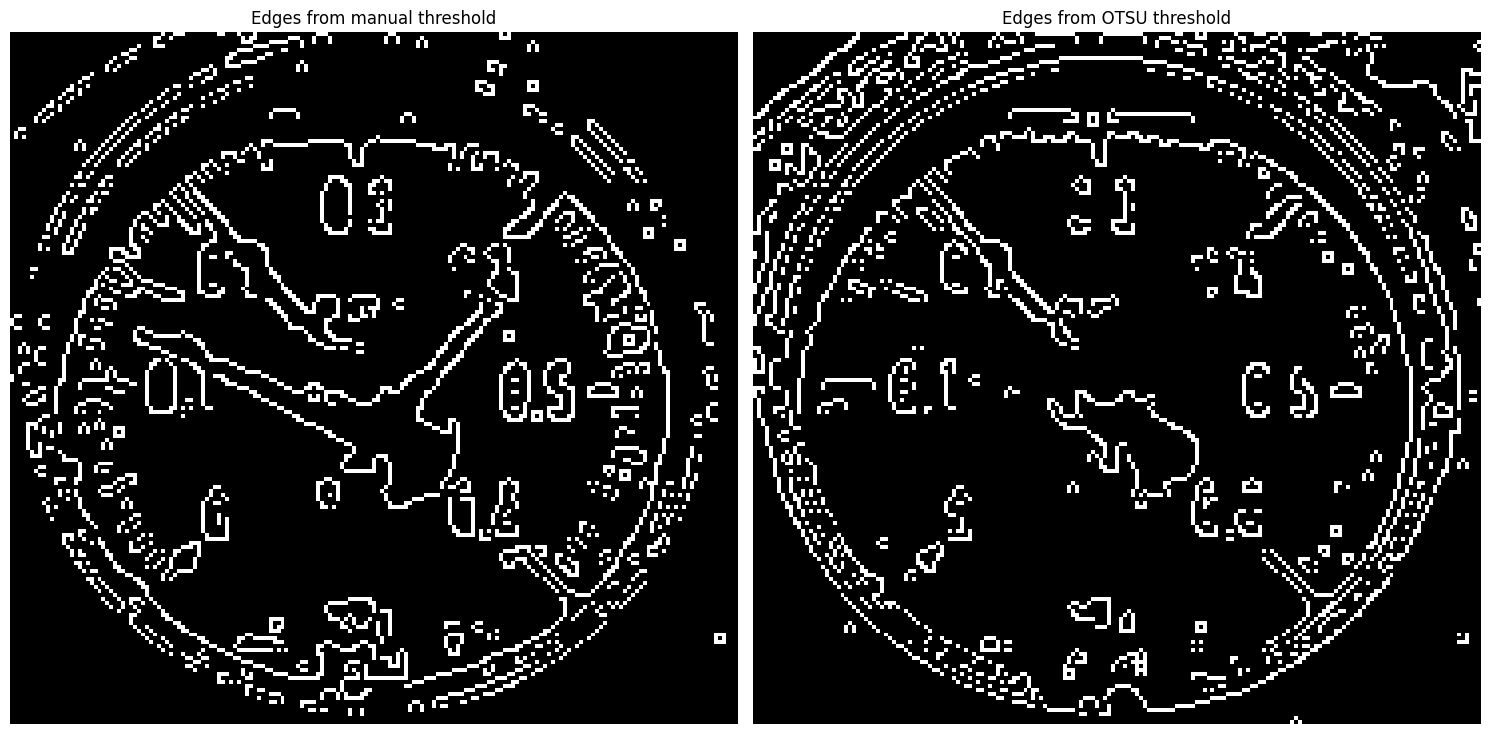

In [60]:
# 原来的固定阈值
edges_thresh_manual = cv2.Canny(thresh_manual, 50, 150)

# OTSU自动阈值
edges_thresh_otsu = cv2.Canny(thresh_otsu, 50, 150)

# 对比显示
plt.figure(figsize=(15, 8))

# 边缘检测对比
plt.subplot(121)
plt.imshow(edges_thresh_manual, cmap='gray')
plt.title('Edges from manual threshold')
plt.axis('off')

plt.subplot(122)
plt.imshow(edges_thresh_otsu, cmap='gray')
plt.title('Edges from OTSU threshold')
plt.axis('off')

plt.tight_layout()
plt.show()

In [79]:
# 1. 检测直线 → 2. 存储坐标 → 3. 在原图绘制红色线段 → 4. 显示结果
lines = cv2.HoughLinesP(edges_thresh_otsu, 1, np.pi / 180, threshold=50, minLineLength=40, maxLineGap=5)
print(f"The starting point and ending point of the detected lines: {lines}")

The starting point and ending point of the detected lines: [[[ 43  36  81  77]]

 [[ 65  19 109  20]]

 [[ 24   8  64   6]]]


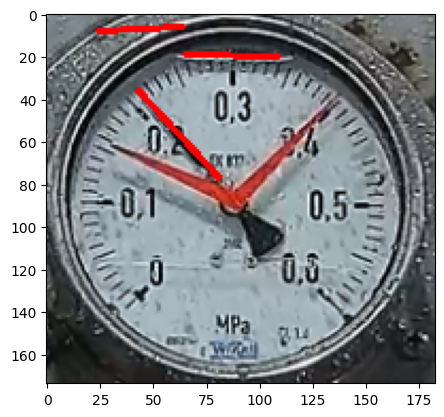

In [80]:
img_pointer = img.copy()
# 存储检测到的直线
detected_lines = []
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        detected_lines.append([x1, y1, x2, y2])
        # 在原图上绘制直线
        cv2.line(img_pointer, (x1, y1), (x2, y2), (0, 0, 255), 2)

img_pointer = cv2.cvtColor(img_pointer, cv2.COLOR_BGR2RGB)
plt.imshow(img_pointer)
plt.show()

In [ ]:
circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, 1, 20,
                           param1=50, param2=30, minRadius=100, maxRadius=170)
circle_info = []
if circles is not None:
    circles = np.round(circles[0, :]).astype("int")
    (x, y, r) = circles[0]
    print(x ,y)
    circle_info = [x, y, r]
    cv2.circle(img, (x, y), r, (0, 0, 255), 2)
    cv2.circle(img, (x, y), 3, (255, 0, 0), 3)


plt.imshow(img)
plt.show()

In [ ]:
circles = cv2.HoughCircles(blurred,cv2.HOUGH_GRADIENT, 1, 20,param1=50,param2=30, minRadius=100, maxRadius=300)
circle_info = []
if circles is not None:
    (x_init, y_init, r_init) = circles[0][0]
    print(f"x_init: {x_init}, y_init: {y_init}, r_init: {r_init}")
    circles = np.round(circles[0,:]).astype("int")
    (x, y, r) = circles[0]
    circle_info = [x, y, r]
    print("-----------------------------")
    print(circle_info)
    # 画圆圈
    # cv2.circle(img, (x, y), r, (0, 255,0), 2)

    # 画圆心点
    cv2.circle(img, (x, y), 3, (255, 255,255), -1)  # 红色实心圆点

    # 可选：添加标签
    cv2.putText(img, f'Center({x},{y})',(x+10, y-10), cv2.FONT_HERSHEY_SIMPLEX,0.9, (0, 255, 0), 1)

plt.imshow(img)
plt.show()

In [ ]:
# 使用概率霍夫变换检测直线
lines = cv2.HoughLinesP(
    edges_thresh_manual,
    rho=1,
    theta=np.pi/180,
    threshold=100,
    minLineLength=70,
    maxLineGap=10
)

print('lines: ', lines)
img_pointer = img.copy()
# 存储检测到的直线
detected_lines = []
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        detected_lines.append([x1, y1, x2, y2])
        # 在原图上绘制直线
        cv2.line(img_pointer, (x1, y1), (x2, y2), (0, 0, 255), 2)

img_pointer = cv2.cvtColor(img_pointer, cv2.COLOR_BGR2RGB)
plt.imshow(img_pointer)
plt.show()

In [ ]:
# 合并显示：红色区域与蓝色圆圈的交点 + 检测直线与蓝色圆圈的交点
img_combined_intersections = img.copy()

# 使用已检测到的圆心坐标和半径的一半
center_x, center_y, radius = circle_info
# 转换为整数类型
# center_x, center_y, radius = int(center_x), int(center_y), int(radius)
half_radius = radius // 2

# 绘制蓝色圆圈（半径为原来的一半）
cv2.circle(img_combined_intersections, (center_x, center_y), half_radius, (255, 0, 0), 2)
# plt.imshow(img_combined_intersections， cmap='gray')
# plt.show()
cv2.imshow('Combined Intersections', img_combined_intersections)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
# 1. 找到红色区域掩码与蓝色圆圈的交点
# 创建蓝色圆圈的掩码
circle_mask = np.zeros_like(red_region_mask)
cv2.circle(circle_mask, (center_x, center_y), half_radius, 255, 1)
plt.imshow(circle_mask, cmap='gray')
plt.show()



In [ ]:
# 找到红色区域掩码与蓝色圆圈的交点
intersection_mask = cv2.bitwise_and(red_region_mask, circle_mask)
# 方法1：单独显示交点
plt.figure(figsize=(15, 5))
plt.subplot(141)
plt.imshow(red_region_mask, cmap='gray')
plt.title('Red region mask')

plt.subplot(142)
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle mask')

plt.subplot(143)
plt.imshow(intersection_mask,cmap='gray')
plt.title('Intersection points')

plt.subplot(144)
# 叠加显示在原图上
overlay = img.copy()
overlay[intersection_mask > 0] = [0, 255,255]  # 黄色标记交点
plt.imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB))
plt.title('Intersection on original')
plt.show()


In [ ]:
overlay = img.copy()
intersection_coords = np.where(intersection_mask > 0)
for y, x in zip(intersection_coords[0],intersection_coords[1]):
    cv2.circle(overlay, (x, y), 3, (0,255, 255), -1)  # 半径3的实心圆
    # cv2.circle(overlay, (x, y), 5, (0, 255, 255), -1)  # 更大的圆

plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))

In [ ]:
# 找到所有交点的坐标
intersection_coords = np.where(intersection_mask > 0)
red_blue_intersection_points = []
for y, x in zip(intersection_coords[0], intersection_coords[1]):
    red_blue_intersection_points.append((x, y))
print(f"红色区域与蓝色圆圈的交点数量: {len(red_blue_intersection_points)}")

In [ ]:
# 2. 找到检测到的直线与蓝色圆圈的交点
lines_blue_intersection_points = []

for line in detected_lines:
    x1, y1, x2, y2 = line

    # 计算直线方程的参数
    if x2 - x1 == 0:  # 垂直线
        # 特殊处理垂直线
        x_line = x1
        # 计算与圆的交点
        discriminant = half_radius**2 - (x_line - center_x)**2
        if discriminant >= 0:
            y_offset = np.sqrt(discriminant)
            y_int1 = center_y + y_offset
            y_int2 = center_y - y_offset
            # 检查交点是否在线段范围内
            if min(y1, y2) <= y_int1 <= max(y1, y2):
                lines_blue_intersection_points.append((int(x_line), int(y_int1)))
            if min(y1, y2) <= y_int2 <= max(y1, y2):
                lines_blue_intersection_points.append((int(x_line), int(y_int2)))
    else:
        # 计算直线斜率和截距
        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1

        # 圆的方程: (x - center_x)^2 + (y - center_y)^2 = half_radius^2
        # 直线方程: y = slope * x + intercept
        # 联立求解交点
        a = 1 + slope**2
        b = 2 * slope * (intercept - center_y) - 2 * center_x
        c = center_x**2 + (intercept - center_y)**2 - half_radius**2

        discriminant = b**2 - 4*a*c

        if discriminant >= 0:
            x_int1 = (-b + np.sqrt(discriminant)) / (2*a)
            x_int2 = (-b - np.sqrt(discriminant)) / (2*a)
            y_int1 = slope * x_int1 + intercept
            y_int2 = slope * x_int2 + intercept

            # 检查交点是否在线段范围内
            if (min(x1, x2) <= x_int1 <= max(x1, x2) and
                min(y1, y2) <= y_int1 <= max(y1, y2)):
                lines_blue_intersection_points.append((int(x_int1), int(y_int1)))

            if (min(x1, x2) <= x_int2 <= max(x1, x2) and
                min(y1, y2) <= y_int2 <= max(y1, y2)):
                lines_blue_intersection_points.append((int(x_int2), int(y_int2)))

# 绘制检测到的直线
for line in detected_lines:
    x1, y1, x2, y2 = line
    cv2.line(img_combined_intersections, (x1, y1), (x2, y2), (0, 255, 0), 2)

# 绘制红色区域与蓝色圆圈的交点（用黄色表示）
for point in red_blue_intersection_points:
    cv2.circle(img_combined_intersections, point, 3, (0, 255, 255), -1)

# 绘制检测直线与蓝色圆圈的交点（用红色表示）
for point in lines_blue_intersection_points:
    cv2.circle(img_combined_intersections, point, 3, (0, 0, 255), -1)

# 转换为RGB并显示
img_combined_intersections_rgb = cv2.cvtColor(img_combined_intersections, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 10))
plt.imshow(img_combined_intersections_rgb)
plt.title('Combined Intersections: Red Region (Yellow dots) + Detected Lines (Red dots) with Blue Circle')


plt.show()

print(f"红色区域与蓝色圆圈的交点数量: {len(red_blue_intersection_points)}")
print(f"检测直线与蓝色圆圈的交点数量: {len(lines_blue_intersection_points)}")
print(f"红色区域交点坐标: {red_blue_intersection_points[:40] if len(red_blue_intersection_points) > 5 else red_blue_intersection_points}")
print(f"直线交点坐标: {lines_blue_intersection_points}")

In [ ]:
# 点A和B：使用连通组件分析分离各个弧线段并确定各弧线段的均值点
point_A = None
point_B = None

if len(red_blue_intersection_points) >= 2:
    # 使用连通组件分析分离各个弧线段
    num_labels, labels = cv2.connectedComponents(intersection_mask)
    print(f"检测到的连通组件数量: {num_labels}")
    arc_mean_points = []
    arc_info = []

    # 为每个连通组件（弧线段）计算均值坐标
    for i in range(1, num_labels):  # 从1开始，跳过背景标签0，实际连通区域数 = num_labels - 1 = 2个
        #  num_labels = 3 表示：
        #   - 标签0: 背景区域（黑色像素）
        #   - 标签1: 第1个连通的白色像素组
        #   - 标签2: 第2个连通的白色像素组
        arc_mask = (labels == i)
        arc_coords = np.where(arc_mask)

        if len(arc_coords[0]) > 0:  # 确保弧线段不为空
            mean_y = np.mean(arc_coords[0])
            mean_x = np.mean(arc_coords[1])
            mean_point = (mean_x, mean_y)
            arc_mean_points.append(mean_point)
            arc_info.append({'id': i, 'mean_point': mean_point})

    # 根据x坐标对弧线段进行排序，确保A在左，B在右
    if len(arc_mean_points) >= 2:
        sorted_arcs = sorted(arc_info, key=lambda info: info['mean_point'][0])
        point_A = sorted_arcs[0]['mean_point']
        point_B = sorted_arcs[1]['mean_point']
    elif len(arc_mean_points) == 1:
        point_A = arc_mean_points[0]
    print(f"弧线段均值点: {arc_mean_points}")
    print(f"点A: {point_A}, 点B: {point_B}")

if point_A is not None:
    point_A = (int(point_A[0]), int(point_A[1]))
if point_B is not None:
    point_B = (int(point_B[0]), int(point_B[1]))

In [ ]:
import json
    # 使用connectedComponentsWithStats获取两个坐标点
if len(red_blue_intersection_points) >= 2:
        # 使用connectedComponentsWithStats分离各个弧线段
    num_labels, labels, stats, centroids =cv2.connectedComponentsWithStats(intersection_mask)

    coordinates = []

    # 跳过背景标签0，从1开始处理实际的连通组件
    for i in range(1, num_labels):
        # 从centroids获取质心坐标 (x, y)
        centroid_x, centroid_y = centroids[i]
        coordinates.append([centroid_x, centroid_y])

        # 根据x坐标排序
        coordinates.sort(key=lambda point: point[0])

        # JSON格式输出两个坐标
        result = {
            "coordinates": coordinates
        }

    print(json.dumps(result))

In [ ]:
num_labels, labels = cv2.connectedComponents(intersection_mask)

# 改成2x2排列
plt.figure(figsize=(12, 10))

plt.subplot(221)
plt.imshow(intersection_mask,cmap='gray')
plt.title('Original intersection mask')
plt.axis('off')

plt.subplot(222)
plt.imshow(labels, cmap='viridis')  # 不同标签显示不同颜色
plt.title(f'Connected Components Label Map ({num_labels-1} components)')
plt.colorbar()

plt.subplot(223)
# 创建彩色显示
colored_labels = cv2.applyColorMap((labels * 255 // num_labels).astype(np.uint8), cv2.COLORMAP_JET)
plt.imshow(cv2.cvtColor(colored_labels, cv2.COLOR_BGR2RGB))
plt.title('Colored connected components')
plt.axis('off')

plt.subplot(224)
# 显示不同连通组件用不同颜色
overlay = img.copy()
colors = [(0, 0, 255), (0, 255, 0), (255,0, 0), (0, 255, 255), (255, 0, 255)]  # 红绿蓝黄紫

for i in range(1, num_labels):  # 从1开始，跳过背景
    component_mask = (labels == i)
    component_coords = np.where(component_mask)

    if len(component_coords[0]) > 0:
        # 给每个连通组件不同颜色
        color = colors[(i-1) % len(colors)]
        for y, x in zip(component_coords[0],component_coords[1]):
            cv2.circle(overlay, (x, y),4, color, -1)

        # 标记组件中心点
        mean_y = int(np.mean(component_coords[0]))
        mean_x = int(np.mean(component_coords[1]))
        cv2.putText(overlay, f'C{i}',(mean_x+10, mean_y),cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

plt.imshow(cv2.cvtColor(overlay,
cv2.COLOR_BGR2RGB))
plt.title('Connected Components (different colors)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 创建可视化图像
display_img = cv2.cvtColor(intersection_mask, cv2.COLOR_GRAY2BGR)

colors = [(0, 255, 0), (0, 0, 255), (255, 0, 0), (255, 255, 0), (255, 0, 255)]

for i in range(1, num_labels):
    arc_mask = (labels == i)
    arc_coords = np.where(arc_mask)

    if len(arc_coords[0]) > 0:
          # 给弧线段着色
          color = colors[(i-1) % len(colors)]
          display_img[arc_mask] = color

          # 计算并标记中心点
          mean_y = int(np.mean(arc_coords[0]))
          mean_x = int(np.mean(arc_coords[1]))

          # 画中心点
          cv2.circle(display_img, (mean_x, mean_y), 2, (255, 255, 255), -1)
          cv2.putText(display_img, f'Arc{i}', (mean_x+10, mean_y),
                     cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
plt.title('Analysis results of arc segments')
plt.axis('off')
plt.show()

In [ ]:
import math

def calculate_clockwise_angle(start_point, center, end_point):
    """
    以 center 为顶点，计算从向量 (center -> start_point) 顺时针旋转到
    向量 (center -> end_point) 的角度。

    参数:
    start_point: 起始向量的终点坐标 (x, y)
    center: 顶点坐标 (x, y)
    end_point: 结束向量的终点坐标 (x, y)

    返回值:
    顺时针角度 (0-360度)
    """
    # 1. 创建从顶点到各点的向量
    # 注意：在图像坐标系中，y轴通常是向下的。
    # 为了与标准的数学坐标系（y轴向上）一致，我们将y坐标取反。
    vec_start = (start_point[0] - center[0], -(start_point[1] - center[1]))
    vec_end = (end_point[0] - center[0], -(end_point[1] - center[1]))

    # 2. 使用 atan2 计算每个向量与x轴正方向的夹角（弧度）
    # atan2(y, x) 返回值范围是 (-pi, pi]，从x轴正方向逆时针为正。
    angle_start = math.atan2(vec_start[1], vec_start[0])
    angle_end = math.atan2(vec_end[1], vec_end[0])

    # 3. 计算角度差（逆时针）
    # 结果是 end_point 相对于 start_point 的逆时针旋转角度
    angle_diff_ccw = angle_end - angle_start

    # 4. 将逆时针角度转换为顺时针角度
    # 如果角度差为负，说明是顺时针旋转，取绝对值即可。
    # 如果角度差为正，说明是逆时针旋转，用360度减去它得到顺时针角度。
    if angle_diff_ccw <= 0:
        angle_diff_cw = -angle_diff_ccw
    else:
        angle_diff_cw = 2 * math.pi - angle_diff_ccw

    # 5. 将弧度转换为度数
    return math.degrees(angle_diff_cw)

# 在原图上显示圆圈与交点信息（四个关键点：A、B、C、O）
img_original_with_detection = img.copy()

# 使用已检测到的圆心坐标和半径
center_x, center_y, radius = circle_info
# 转换为整数类型
center_x, center_y, radius = int(center_x), int(center_y), int(radius)
half_radius = radius // 2

# 绘制原始检测到的圆圈（绿色）
cv2.circle(img_original_with_detection, (center_x, center_y), radius, (0, 255, 0), 3)

# 绘制半径圆圈（蓝色）
cv2.circle(img_original_with_detection, (center_x, center_y), half_radius, (255, 0, 0), 2)


# 找到所有交点的坐标
intersection_coords = np.where(intersection_mask > 0)
red_blue_intersection_points = []
for y, x in zip(intersection_coords[0], intersection_coords[1]):
    red_blue_intersection_points.append((x, y))

# 2. 找到检测到的直线与蓝色圆圈的交点
lines_blue_intersection_points = []

for line in detected_lines:
    x1, y1, x2, y2 = line

    # 计算直线方程的参数
    if x2 - x1 == 0:  # 垂直线
        # 特殊处理垂直线
        x_line = x1
        # 计算与圆的交点
        discriminant = half_radius**2 - (x_line - center_x)**2
        if discriminant >= 0:
            y_offset = np.sqrt(discriminant)
            y_int1 = center_y + y_offset
            y_int2 = center_y - y_offset
            # 检查交点是否在线段范围内
            if min(y1, y2) <= y_int1 <= max(y1, y2):
                lines_blue_intersection_points.append((int(x_line), int(y_int1)))
            if min(y1, y2) <= y_int2 <= max(y1, y2):
                lines_blue_intersection_points.append((int(x_line), int(y_int2)))
    else:
        # 计算直线斜率和截距
        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1

        # 圆的方程: (x - center_x)^2 + (y - center_y)^2 = half_radius^2
        # 直线方程: y = slope * x + intercept
        # 联立求解交点
        a = 1 + slope**2
        b = 2 * slope * (intercept - center_y) - 2 * center_x
        c = center_x**2 + (intercept - center_y)**2 - half_radius**2

        discriminant = b**2 - 4*a*c

        if discriminant >= 0:
            x_int1 = (-b + np.sqrt(discriminant)) / (2*a)
            x_int2 = (-b - np.sqrt(discriminant)) / (2*a)
            y_int1 = slope * x_int1 + intercept
            y_int2 = slope * x_int2 + intercept

            # 检查交点是否在线段范围内
            if (min(x1, x2) <= x_int1 <= max(x1, x2) and
                min(y1, y2) <= y_int1 <= max(y1, y2)):
                lines_blue_intersection_points.append((int(x_int1), int(y_int1)))

            if (min(x1, x2) <= x_int2 <= max(x1, x2) and
                min(y1, y2) <= y_int2 <= max(y1, y2)):
                lines_blue_intersection_points.append((int(x_int2), int(y_int2)))
# 绘制检测到的直线（亮绿色）
for line in detected_lines:
    x1, y1, x2, y2 = line
    cv2.line(img_original_with_detection, (x1, y1), (x2, y2), (0, 255, 150), 1)


# 3. 计算四个关键点
# 点O：圆心
point_O = (center_x, center_y)



# 点C：直线交点的均值点
point_C = None
if lines_blue_intersection_points:
    point_C = (int(np.mean([p[0] for p in lines_blue_intersection_points])),
               int(np.mean([p[1] for p in lines_blue_intersection_points])))

# 5. 计算夹角
angle_AOB_cw = 0
angle_COB_cw = 0
angle_AOC_cw = 0

if point_A and point_B:
    angle_AOB_cw = calculate_clockwise_angle(point_A, point_O, point_B)

if point_B and point_C:
    angle_COB_cw = calculate_clockwise_angle(point_C, point_O, point_B)

if point_A and point_C:
    angle_AOC_cw = calculate_clockwise_angle(point_A, point_O, point_C)

# 6. 绘制四个关键点（使用小圆点标记）
# 点O：圆心（白色小圆点）
cv2.circle(img_original_with_detection, point_O, 3, (255, 255, 255), -1)
cv2.putText(img_original_with_detection, 'O', (point_O[0]+8, point_O[1]-8),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

# 点A：红色区域交点簇1的均值（黄色小圆点）
if point_A:
    cv2.circle(img_original_with_detection, point_A, 3, (0, 255, 255), -1)
    cv2.putText(img_original_with_detection, 'A', (point_A[0]+8, point_A[1]-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

# 点B：红色区域交点簇2的均值（橙色小圆点）
if point_B:
    cv2.circle(img_original_with_detection, point_B, 3, (0, 165, 255), -1)
    cv2.putText(img_original_with_detection, 'B', (point_B[0]+8, point_B[1]-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 165, 255), 2)

# 点C：直线交点的均值（红色小圆点）
if point_C:
    cv2.circle(img_original_with_detection, point_C, 3, (0, 0, 255), -1)
    cv2.putText(img_original_with_detection, 'C', (point_C[0]+8, point_C[1]-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

# 7. 绘制夹角辅助线（可选）
if point_A:
    # 绘制OA线（虚线效果，用多个小圆点）
    pts_OA = np.linspace(point_O, point_A, 20).astype(int)
    for pt in pts_OA[::3]:  # 每隔3个点画一个
        cv2.circle(img_original_with_detection, tuple(pt), 1, (0, 255, 255), -1)

if point_B:
    # 绘制OB线（虚线效果）
    pts_OB = np.linspace(point_O, point_B, 20).astype(int)
    for pt in pts_OB[::3]:
        cv2.circle(img_original_with_detection, tuple(pt), 1, (0, 165, 255), -1)

if point_C:
    #  # 绘制OC线（连续直线效果）
    # cv2.line(img_original_with_detection, point_O, point_C, (0, 0, 255), 2)
    # 绘制OC线（虚线效果）
    pts_OC = np.linspace(point_O, point_C, 20).astype(int)
    for pt in pts_OC[::3]:
        cv2.circle(img_original_with_detection, tuple(pt), 1, (0, 0, 255), -1)

# 转换为RGB并显示
img_original_with_detection_rgb = cv2.cvtColor(img_original_with_detection, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(16, 12))
plt.imshow(img_original_with_detection_rgb)
plt.title('Original Image with Four Key Points (A, B, C, O) - Clockwise Angle', fontsize=16, weight='bold')

# 添加夹角信息到图像上
if point_A and point_B:
    angle_text = f'∠AOB = {angle_AOB_cw:.1f}°'
    plt.text(10, 50, angle_text, fontsize=16, color='cyan', weight='bold',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="black", alpha=0.7))

if point_B and point_C:
    angle_text = f'∠COB = {angle_COB_cw:.1f}°'
    plt.text(10, 90, angle_text, fontsize=16, color='orange', weight='bold',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="black", alpha=0.7))

if point_A and point_C:
    angle_text = f'∠AOC = {angle_AOC_cw:.1f}°'
    plt.text(10, 130, angle_text, fontsize=16, color='magenta', weight='bold',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="black", alpha=0.7))

plt.axis('off')  # 隐藏坐标轴
plt.tight_layout()
plt.show()

print(f"四个关键点检测结果总结 :")
print(f"============================================")
print(f"点O (圆心): {point_O}")
if point_A:
    print(f"点A (红色区域簇1均值): {point_A}")
if point_B:
    print(f"点B (红色区域簇2均值): {point_B}")
if point_C:
    print(f"点C (直线交点均值): {point_C}")
print(f"============================================")
print(f"顺时针夹角计算结果:")
if point_A and point_B:
    print(f"从 OA 顺时针到 OB 的角度: {angle_AOB_cw:.2f}°")
if point_B and point_C:
    print(f"从 OC 顺时针到 OB 的角度: {angle_COB_cw:.2f}°")
if point_A and point_C:
    print(f"从 OA 顺时针到 OC 的角度: {angle_AOC_cw:.2f}°")
print(f"============================================")
print(f"红色区域总交点数量: {len(red_blue_intersection_points)}")
print(f"直线交点数量: {len(lines_blue_intersection_points)}")
print(f"检测到的直线数量: {len(detected_lines)}")
print(f"圆半径: {radius} 像素，使用半径: {half_radius} 像素")
